
<a href="https://colab.research.google.com/github/aleylani/Databehandling-AI25/blob/main/exercises/E3_merging.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Merging exercises

---
These are introductory exercises in Pandas with focus in **syntax, indexing, data selection, missing data, aggregations, visualizations**, **data cleaning**, **merging**, **concatenation**, **joining**, **parse html tables** .

<p class = "alert alert-info" role="alert"><b>Note</b> all datasets used in this exercise can be found under Data folder of the course Github repo</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that there are usually many ways to achieve same results using operations in pandas. Feel free to investigate several ways. </p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to format your input questions in a pedagogical way to guide the user

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

**Note that you might need to install lxml in your environment**

## 1. Swedish demographic data (*)

Go to Swedish-language wikipedia page [Sveriges demografi](https://sv.wikipedia.org/wiki/Sveriges_demografi). 

&nbsp; a) Read in the table under "Befolkningsstatistik sedan 1900" into a DataFrame

          Note that you might need to install lxml in your environment

          conda install lxml


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import requests
import lxml
import html5lib

url = "https://sv.wikipedia.org/wiki/Sveriges_demografi"
 
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"}
 
resp = requests.get(url, headers=headers, timeout=30)
 
            # will raise if something's wrong
dfs = pd.read_html(resp.text, attrs={"class": "wikitable"})  # optional filter
print(len(dfs), "tables")


3 tables


/var/folders/v6/gq67wv2j7g9fgp90bcj22ll80000gn/T/ipykernel_25834/3099830957.py:18: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(resp.text, attrs={"class": "wikitable"})  # optional filter


&nbsp; b) Choose to do some EDA (exploratory data analysis) on this dataset. And draw some relevant graphs.


&nbsp; c) Now we want to go backwards in time (before 1900) to see how population has changed in Sweden. Read in the table under history and keep the data of "Folkmängd" from 1570-1865. 



&nbsp; d) Now concatenate this with the table from 1900 so that you have population data from 1570 to 2020. Note that you may need to clean the data in order for it to fit properly. Also you may be able to do this in several ways. 


In [2]:
# SPARA I SEPARAT DF
soll_df = dfs[0]

# SNITTAR UT ÅR TILL SERIE OCH OMVANDLAR TILL INT
år_df = soll_df.loc[0:9, ["Vid utgången av år"]].astype(int)
år_s = pd.Series(år_df["Vid utgången av år"].squeeze())
år_s.name = "år"

# SNITTAR UT FOLKMÄNGD TILL SERIE
mängd_df = soll_df.loc[0:9, ["Folkmängd"]]
mängd_s = pd.Series(mängd_df["Folkmängd"].squeeze())
mängd_s.name = "antal"
# TAR BORT SKITKONSTIGT MELLANRUM OCH OMVANDLAR TILL INT
mängd_s = mängd_s.str.replace("\xa0", "").astype(int)

# MERGAR SERIER OCH DROPPAR ON
nya_år_df = pd.merge(år_s, mängd_s, how="inner", on=år_s).drop(columns="key_0")

# SAMMA PROCEDUR FÖR ÄLDRE TABELL
gamla_år_s = pd.Series([1570, 1650, 1700, 1720, 1755, 1815, 1865], name='år')
gamla_mängd_s = pd.Series([900000, 1225000, 1485000, 1350000, 1878000, 2465000, 4099000], name='antal')
gamla_år_df = pd.merge(gamla_år_s, gamla_mängd_s, how="left", on=gamla_år_s).drop(columns="key_0")

alla_år_df = pd.concat([gamla_år_df, nya_år_df]).reset_index(drop=True)




&nbsp; e) Draw a graph of population data from 1570-2020.


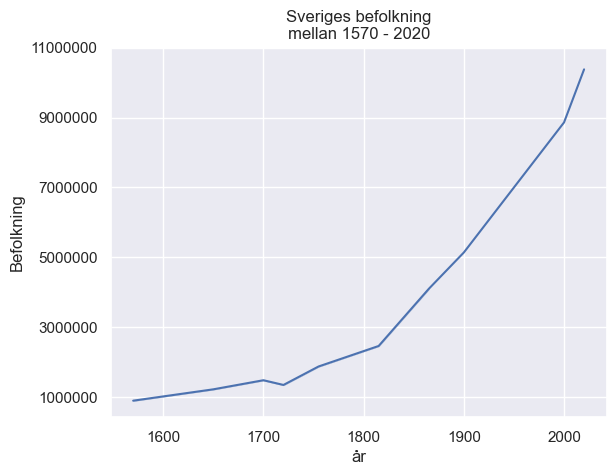

In [3]:
sns.set_theme(style="darkgrid")
sns.lineplot(data=alla_år_df, x="år", y="antal")
plt.ylabel("Befolkning")
plt.yticks(ticks=np.arange(1000000,12000000,step=2000000))
plt.ticklabel_format(style="plain")

plt.title("Sveriges befolkning\nmellan 1570 - 2020")
plt.show()


&nbsp; f) Try to see if you can plot something from this data that might show the effects of the Covid-19 pandemic. It's good to zoom in the data, i.e. plot a shorter time frame instead of all time frames. 


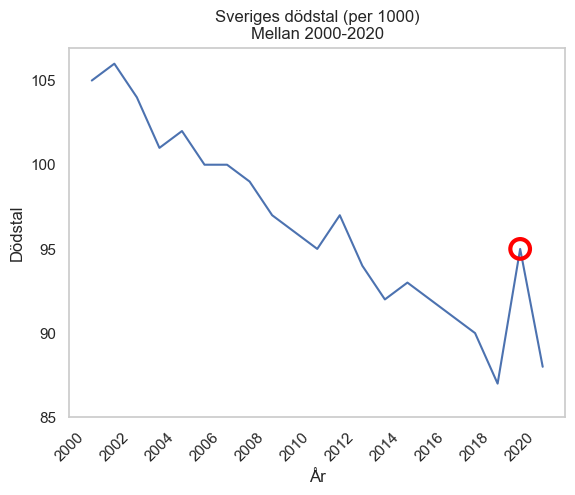

In [47]:
# IMPORTERA TABLE MED DÖDSTAL
swe_df = pd.read_csv("data/cleaned_table.csv")

# SORTERA PÅ ÅR OCH SÄTTA ÅR SOM INDEX
swe_df.sort_values(by="År", inplace=True)
swe_df.reset_index(drop=True)


# SKÄR UT DE RELEVANTA ÅREN
år_mask = (swe_df["År"] > 2000) & (swe_df["År"] < 2022)
swe3_df = swe_df.loc[år_mask, ["År", 'Dödstal" "(per 1000)']]

# SNYGGA TILL HEADERS
swe3_df.rename(columns={"År":"År", 'Dödstal" "(per 1000)':"Dödstal"}, inplace=True)

# VISUALISERING AV DÖDSTAL
sns.lineplot(swe3_df, x="År", y="Dödstal")
plt.title("Sveriges dödstal (per 1000)\nMellan 2000-2020")

# VISUALISERING AV HIGHTLIGHT
viktiga_ar = [2020]
viktiga_punkter = swe3_df[swe3_df['År'].isin(viktiga_ar)]

plt.scatter(viktiga_punkter['År'], viktiga_punkter['Dödstal'], 
           s=200,           # Storlek
           facecolors='none',  # Genomskinlig insida
           edgecolors='red',   # Röd kant
           linewidths=3,       # Tjocklek på cirkeln
           zorder=5)           # Rita ovanpå linjen

# SNYGGA TILL AXIS OCH VISUALISERAR

plt.xticks(np.arange(2000,2021,step=2,), rotation=45)
plt.yticks(np.arange(85, 110, step=5))
plt.grid()
plt.show()




&nbsp; g) Try to see if you can plot something from this data that might capture the effects imigration and emigration waves.


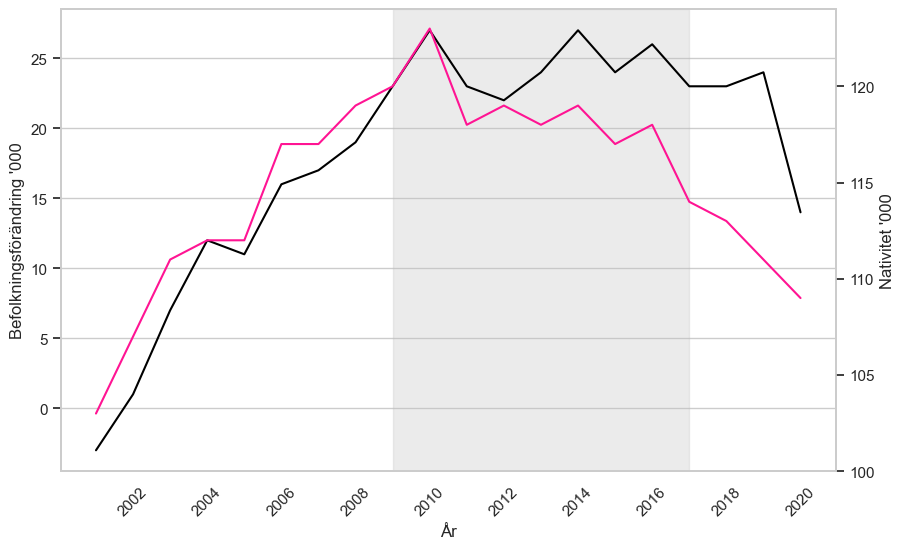

In [48]:
inv_mask = (swe_df["År"] > 2000) & (swe_df["År"] < 2021)
swe_df
inv_df = swe_df.loc[inv_mask, ["År", 'Naturlig" "befolknings-" "förändring" "(per 1000)', 'Nativitet" "(per 1000)']].rename(columns={"År":"År", 'Naturlig" "befolknings-" "förändring" "(per 1000)': "Befolkningsförändring '000", 'Nativitet" "(per 1000)':"Nativitet '000"}).reset_index(drop=True)


fig,ax1 = plt.subplots(figsize=(10,6))

# MARKERING
ax1.axvspan(2009, 2017, alpha=0.3, color='silver')

# VISUALISERING AV PRIMÄRAXLAR
sns.lineplot(data=inv_df, x="År", y="Befolkningsförändring '000", ax=ax1, color="black")
plt.grid(axis="x")
plt.xticks(np.arange(2000,2021,step=2), rotation=45)

# SEKUNDÄRAXEL
ax2 = ax1.twinx()
sns.lineplot(data=inv_df, x="År", y="Nativitet '000", ax=ax2, color="deeppink")
ax2.set_yticks(np.arange(100,125,step=5))
plt.grid(None)

sns.set_theme(style="whitegrid")


plt.show()




&nbsp; h) Feel free to find other interesting facts about the Swedish demographics based on this data. 


In [6]:
swe_df.head()

,År,"Medel-"" ""folkmängd",Födda,Döda,"Naturlig"" ""befolknings-"" ""förändring","Nativitet"" ""(per 1000)","Dödstal"" ""(per 1000)","Naturlig"" ""befolknings-"" ""förändring"" ""(per 1000)",Total fertilitet
1,1900,5117000.0,138139,86146,51993,270.0,168.0,102.0,402.0
0,1901,5156000.0,139370,82772,56598,270.0,161.0,110.0,404.0
2,1902,5187000.0,137364,79722,57642,265.0,154.0,111.0,395.0
5,1903,5210000.0,133896,78610,55286,257.0,151.0,106.0,382.0
3,1904,5241000.0,134952,80152,54800,257.0,153.0,105.0,383.0


In [7]:
dfs[2]

,Åldersgrupp,Män (%),Kvinnor (%)
0,0-4 år,"51,47%","48,53%"
1,5-14 år,"51,44%","48,56%"
2,15-24 år,"52,13%","47,87%"
3,25-34 år,"51,41%","48,59%"
4,35-44 år,"51,04%","48,96%"
5,45-54 år,"50,78%","49,22%"
6,55-64 år,"50,22%","49,78%"
7,65-74 år,"49,14%","50,86%"
8,75-84 år,"45,92%","54,08%"
9,85-94 år,"36,16%","63,84%"


In [ ]:

url = "https://da.wikipedia.org/wiki/Danmarks_demografi"
 
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"}
 
resp = requests.get(url, headers=headers, timeout=30)
 
dk_dfs = pd.read_html(resp.text, attrs={"class": "wikitable"}) 
print(len(dk_dfs), "tables")


2 tables


/var/folders/v6/gq67wv2j7g9fgp90bcj22ll80000gn/T/ipykernel_25834/1459668856.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dk_dfs = pd.read_html(resp.text, attrs={"class": "wikitable"})  # optional filter


---
## 2. Denmark demographic data (*)

Go to the Danish-language wikipedia page [Danmarks demografi](https://da.wikipedia.org/wiki/Danmarks_demografi). 

&nbsp; a) Read in the table under "Demografiske data" into a DataFrame (*)

&nbsp; b) Clean the data and draw a graph of population against year from 1769-2020. (**)


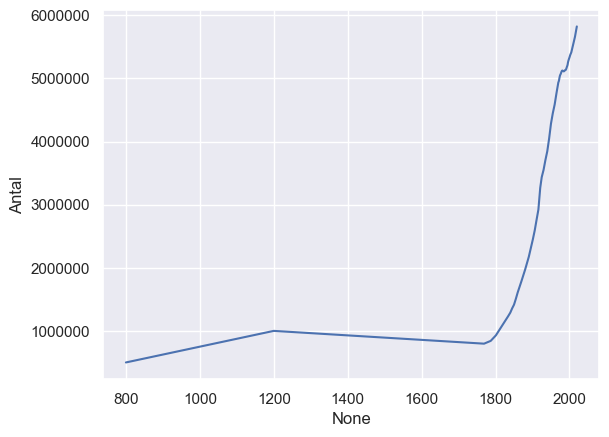

In [51]:
dk_df = dk_dfs[0] 
dk1_df = dk_df.iloc[:,[0,1]].rename(columns={"År":"År", "Befolkning pr. 1. januar":"Antal"}).set_index("År", drop=True)
dk2_df = dk_df.iloc[2:,[2,3]].rename(columns={"År.1":"År", "Befolkning pr. 1. januar.1":"Antal"}).set_index("År", drop=True)

stor_dk = pd.concat([dk1_df, dk2_df])

stor_dk.index = [int(x) for x in stor_dk.index]


stor_dk["Antal"] = stor_dk["Antal"].str.replace(".","")
stor_dk.loc[[800],"Antal"] = int(500000)
stor_dk.loc[[1200],"Antal"] = int(1000000)
stor_dk["Antal"] = stor_dk["Antal"].values.astype(int)
sns.lineplot(data=stor_dk, x=stor_dk.index, y="Antal")
sns.set_theme(style="darkgrid")

plt.ticklabel_format(style="plain")



---
## 3. Norwegian demographic data (*)

Go to Swedish-language wikipedia page [Norges demografi](https://sv.wikipedia.org/wiki/Norges_demografi). 

&nbsp; a) Read in the table under "Befolkningsstatistik sedan 1900" into a DataFrame


In [10]:
# INSTÄLLNING FÖR ATT VISA HELA TABELLEN, EJ AVBRUTNA TABELLER
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# HÄMTA NORSK TABELL FRÅN WIKIPEDIA
url = "https://sv.wikipedia.org/wiki/Norges_demografi"
 
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"}
 
data = requests.get(url, headers=headers, timeout=30)
no_dfs = pd.read_html(data.text, attrs={"class": "wikitable"}) 

print(len(no_dfs), "tables")

4 tables


/var/folders/v6/gq67wv2j7g9fgp90bcj22ll80000gn/T/ipykernel_25834/2166925327.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  no_dfs = pd.read_html(data.text, attrs={"class": "wikitable"})


In [11]:
# IDENTIFIERA RÄTT TABELL
no_dfs[1].head()

,Unnamed: 0,Befolkning i tusentals (x 1000),Födda,Döda,Naturlig förändring,Födelsetal per 1 000 invånare,Dödstal per 1 000 invånare,Naturlig förändring per 1 000 invånare,Total fertilitet
0,1900,2 231,66 229,35 345,30 884,297,158,138,NaN
1,1901,2 255,67 303,33 821,33 482,298,150,148,NaN
2,1902,2 276,66 494,31 670,34 824,292,139,153,NaN
3,1903,2 288,65 470,33 847,31 623,286,148,138,NaN
4,1904,2 298,64 143,32 895,31 248,279,143,136,NaN



&nbsp; b) You see some missing data in column "Total fertilitet". Go to the [English page](https://en.wikipedia.org/wiki/Demographics_of_Norway) and read in the data from "Vital statistics since 1900".  


In [12]:
# KOPIERA TABELL TILL EN WORKING COPY 
no_bef = no_dfs[1]

# IDENTIFIERA DATA SOM SAKNAS
print(f"ANTAL RADER DÄR FERTILITET SAKNAS: {no_bef["Total fertilitet"].isna().sum()}")
no_bef[no_bef["Total fertilitet"].isna()]


ANTAL RADER DÄR FERTILITET SAKNAS: 28


,Unnamed: 0,Befolkning i tusentals (x 1000),Födda,Döda,Naturlig förändring,Födelsetal per 1 000 invånare,Dödstal per 1 000 invånare,Naturlig förändring per 1 000 invånare,Total fertilitet
0,1900,2 231,66 229,35 345,30 884,297,158,138,NaN
1,1901,2 255,67 303,33 821,33 482,298,150,148,NaN
2,1902,2 276,66 494,31 670,34 824,292,139,153,NaN
3,1903,2 288,65 470,33 847,31 623,286,148,138,NaN
4,1904,2 298,64 143,32 895,31 248,279,143,136,NaN
5,1905,2 309,62 601,34 050,28 551,271,147,124,NaN
6,1906,2 319,62 091,31 668,30 423,268,137,131,NaN
7,1907,2 329,61 302,33 345,27 957,263,143,120,NaN
8,1908,2 346,61 686,33 366,28 320,263,142,121,NaN
9,1909,2 368,63 324,32 111,31 213,267,136,132,NaN


In [13]:

# SNYGGA TILL RUBRIKER SOM ÄR VIKTIGA
no_tabell = no_bef.rename(columns={"Befolkning i tusentals (x 1000)":"Folkmängd"})
no_tabell = no_tabell.rename(columns={"Unnamed: 0":"År"})

#UPPTÄCKTE KNAS I DATAN FOLKMÄNGD
print(type(no_tabell["Folkmängd"][1]))
no_tabell.head()


<class 'str'>


,År,Folkmängd,Födda,Döda,Naturlig förändring,Födelsetal per 1 000 invånare,Dödstal per 1 000 invånare,Naturlig förändring per 1 000 invånare,Total fertilitet
0,1900,2 231,66 229,35 345,30 884,297,158,138,NaN
1,1901,2 255,67 303,33 821,33 482,298,150,148,NaN
2,1902,2 276,66 494,31 670,34 824,292,139,153,NaN
3,1903,2 288,65 470,33 847,31 623,286,148,138,NaN
4,1904,2 298,64 143,32 895,31 248,279,143,136,NaN


In [14]:

# HARMONISERAR DATA I FOLKMÄNGD (MÄRKLIGT TECKEN SOM BEHÖVDES TAS BORT OCH SEN GÖRA TILL INT*1000 FÖR ATT MATCHA SE DATA
# <r'\s+', '', regex=True> tar bort allting som ses som mellanslag och som kan förekomma flera gånger i strängen
no_tabell["Folkmängd"] = (no_tabell["Folkmängd"].str.replace(r'\s+', '', regex=True).astype(int) * 1000)
no_tabell.head()





,År,Folkmängd,Födda,Döda,Naturlig förändring,Födelsetal per 1 000 invånare,Dödstal per 1 000 invånare,Naturlig förändring per 1 000 invånare,Total fertilitet
0,1900,2231000,66 229,35 345,30 884,297,158,138,NaN
1,1901,2255000,67 303,33 821,33 482,298,150,148,NaN
2,1902,2276000,66 494,31 670,34 824,292,139,153,NaN
3,1903,2288000,65 470,33 847,31 623,286,148,138,NaN
4,1904,2298000,64 143,32 895,31 248,279,143,136,NaN


In [15]:
# HITTAR EJ MATCHANDE DATA FÖR TOTAL FERTILITET PÅ ENGELSK SIDA MEN PÅ https://commons.wikimedia.org/wiki/Data:Norway_TFR.tab 
# SPARAR NER DATAN SOM CSV "Norway TFR.tab.csv"

# TAR FÖRST BORT HELA GAMLA KOLUMNEN PÅ FERTILITET
no_tabell = no_tabell.drop(columns="Total fertilitet")

# TAR IN DEN NYA DATAN SOM ÄR I CSV OCH SPARAR I SEPARAT SNYGG DF
fert = pd.read_csv("data/Norway TFR.tab.csv", index_col=0)
fert = fert.reset_index()
fert2 = fert.rename(columns={"x":"År", "y1":"Total fertilitet"})

print(fert2.head())
print(fert2.tail())


     År  Total fertilitet
0  1900              4.40
1  1901              4.37
2  1902              4.26
3  1903              4.16
4  1904              4.07
       År  Total fertilitet
120  2020              1.48
121  2021              1.55
122  2022              1.41
123  2023              1.40
124  2024              1.44


In [16]:
# LÄGGER IHOP DEN NYA DATATABELLEN MED ORIGINALET

stor_no = pd.merge(no_tabell,fert2,how="inner", on="År")
stor_no.head()


,År,Folkmängd,Födda,Döda,Naturlig förändring,Födelsetal per 1 000 invånare,Dödstal per 1 000 invånare,Naturlig förändring per 1 000 invånare,Total fertilitet
0,1900,2231000,66 229,35 345,30 884,297,158,138,4.40
1,1901,2255000,67 303,33 821,33 482,298,150,148,4.37
2,1902,2276000,66 494,31 670,34 824,292,139,153,4.26
3,1903,2288000,65 470,33 847,31 623,286,148,138,4.16
4,1904,2298000,64 143,32 895,31 248,279,143,136,4.07



&nbsp; c) Pick out the fertility column from b) dataset, merge it into a) dataset and clean the data so that you only have columns "År", "Folkmängd", "Fertilitet". 


In [17]:

# SKÄR UT RELEVANTA KOLUMENER OCH SPARAR I NY DF
c_df = stor_no[["År", "Folkmängd", "Total fertilitet"]]

print("NULLVÄRDEN I RESP KOLUMN")
print(c_df.isna().sum())
c_df.head()



NULLVÄRDEN I RESP KOLUMN
År                  0
Folkmängd           0
Total fertilitet    0
dtype: int64


,År,Folkmängd,Total fertilitet
0,1900,2231000,4.40
1,1901,2255000,4.37
2,1902,2276000,4.26
3,1903,2288000,4.16
4,1904,2298000,4.07


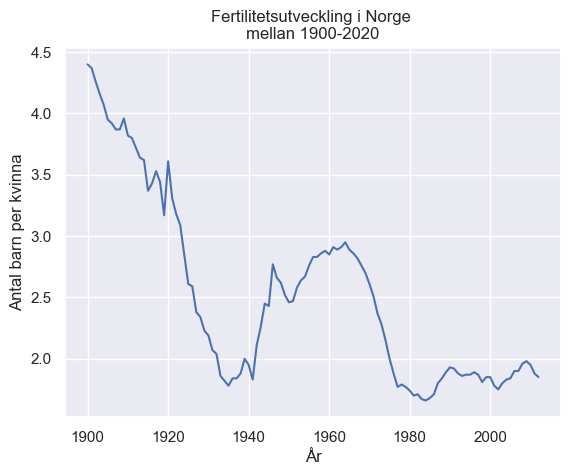

In [18]:
# PLOTTAR DATAN I FUL GRAF
sns.lineplot(data=c_df, x="År", y="Total fertilitet")
plt.ylabel("Antal barn per kvinna")
plt.title("Fertilitetsutveckling i Norge \nmellan 1900-2020")
plt.show()


---
## 4. Merge Sweden-Norway (*)

Create a population graph and a fertility graph showing Sweden and Norway.

<details>

<summary>Answer</summary>

![Fertilitet Norge och Sverige](../assets/fertilitet_sv_no.png)

![Folkmängd Norge och Sverige](../assets/folkmangd_sverige_norge.png)

</details>

In [19]:
# KOPIERA SVENSK DF TILL WORKING COPY OCH KIKAR HUR DET SER UT
s_df = swe_df.copy()
s_df.head()
# SE fertilitetstal har fel format jämf med norge (index istället för heltal) så jag behöver dela varje tal med 100


,År,"Medel-"" ""folkmängd",Födda,Döda,"Naturlig"" ""befolknings-"" ""förändring","Nativitet"" ""(per 1000)","Dödstal"" ""(per 1000)","Naturlig"" ""befolknings-"" ""förändring"" ""(per 1000)",Total fertilitet
1,1900,5117000.0,138139,86146,51993,270.0,168.0,102.0,402.0
0,1901,5156000.0,139370,82772,56598,270.0,161.0,110.0,404.0
2,1902,5187000.0,137364,79722,57642,265.0,154.0,111.0,395.0
5,1903,5210000.0,133896,78610,55286,257.0,151.0,106.0,382.0
3,1904,5241000.0,134952,80152,54800,257.0,153.0,105.0,383.0


In [20]:
# HARMONISERAR RUBRIKER OCH DATA OCH SPARAR DE KOLUMNER JAG BEHÖVER
s_df = s_df.rename(columns={'Medel-" "folkmängd ':'Folkmängd'})

# GÖR OM FERTILITETSSIFFRORNA
s_df["Total fertilitet"] = round(s_df["Total fertilitet"]/100,2) 
s_df.head()



,År,Folkmängd,Födda,Döda,"Naturlig"" ""befolknings-"" ""förändring","Nativitet"" ""(per 1000)","Dödstal"" ""(per 1000)","Naturlig"" ""befolknings-"" ""förändring"" ""(per 1000)",Total fertilitet
1,1900,5117000.0,138139,86146,51993,270.0,168.0,102.0,4.02
0,1901,5156000.0,139370,82772,56598,270.0,161.0,110.0,4.04
2,1902,5187000.0,137364,79722,57642,265.0,154.0,111.0,3.95
5,1903,5210000.0,133896,78610,55286,257.0,151.0,106.0,3.82
3,1904,5241000.0,134952,80152,54800,257.0,153.0,105.0,3.83


In [21]:
# UPPTÄCKER ATT DET SAKNAS TVÅ VÄRDEN I FERTILITET 
s_df = s_df[["År", "Folkmängd", "Total fertilitet"]]
print(s_df.isna().sum())
s_df.tail()


År                  0
Folkmängd           0
Total fertilitet    2
dtype: int64


,År,Folkmängd,Total fertilitet
96,2018,10175213.5,1.75
103,2019,10278887.0,1.70
108,2020,10353442.0,1.66
121,2021,10415810.5,NaN
122,2022,10521556.0,NaN


In [22]:
# -> BESTÄMMER MIG FÖR ATT CUTTA TABELLEN PÅ 2020 FÖR BÅDE SE OCH NO
s_df = s_df[:-2]
s_df.tail()

,År,Folkmängd,Total fertilitet
85,2016,9923085.0,1.85
90,2017,10057697.5,1.79
96,2018,10175213.5,1.75
103,2019,10278887.0,1.70
108,2020,10353442.0,1.66


In [23]:

# GÅR ÖVER TILL NORGES TABELL OCH SER TILL ATT DEN BLIR LIKADAN SOM SE
# NO DATA SLUTAR VID 2012 SÅ LÄGGER PÅ DATA
print(c_df.tail(10))
extra_no = fert2.loc[113:120,["År","Total fertilitet"]]
extra_no


       År  Folkmängd  Total fertilitet
103  2003    4565000              1.80
104  2004    4592000              1.83
105  2005    4623000              1.84
106  2006    4661000              1.90
107  2007    4709000              1.90
108  2008    4768000              1.96
109  2009    4829000              1.98
110  2010    4889000              1.95
111  2011    4953000              1.88
112  2012    5019000              1.85


,År,Total fertilitet
113,2013,1.78
114,2014,1.76
115,2015,1.73
116,2016,1.71
117,2017,1.62
118,2018,1.56
119,2019,1.53
120,2020,1.48


In [24]:
# KLOSSAR PÅ SISTA ÅREN AV FERTILITET MED DEN STORA NO TABELLEN
n_df = pd.concat([c_df, extra_no])

# MEN DÅ SAKNAR JAG NORSK FOLKMÄNGDSDATA SISTA ÅREN OCKSÅ SNAAAARK
n_df.tail(13)


,År,Folkmängd,Total fertilitet
108,2008,4768000.0,1.96
109,2009,4829000.0,1.98
110,2010,4889000.0,1.95
111,2011,4953000.0,1.88
112,2012,5019000.0,1.85
113,2013,NaN,1.78
114,2014,NaN,1.76
115,2015,NaN,1.73
116,2016,NaN,1.71
117,2017,NaN,1.62


In [25]:
# GÅR IN PÅ NORSKA SCB FÖR ATT LETA FOLKMÄNGD SISTA ÅREN, HITTAS HÄR: https://www.ssb.no/statbank2/en/table/05803

# UPPTÄCKER ATT TABELLEN ÄR ÅT FEL HÅLL, BEHÖVER TRANSPONERAS
no_extra_pop = pd.read_csv("data/no_pop.csv", delimiter=";", header=0)
no_extra_pop = no_extra_pop[0:2]
no_extra_pop


,,,,,,,,,,,,,"05803: Population 1 January and population changes during the calendar year, by contents and year"
contents,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025
Population 1 January,5051275.0,5109056.0,5165802.0,5213985.0,5258317.0,5295619.0,5328212.0,5367580.0,5391369.0,5425270.0,5488984.0,5550203.0,5594340


In [26]:
# SNYGGAR TILL INNAN JAG TRANSPONERAR TABELL
no_extra_pop = no_extra_pop.reset_index().rename_axis()
no_extra_pop = no_extra_pop.iloc[:,0:13]
no_extra_pop


,level_0,level_1,level_2,level_3,level_4,level_5,level_6,level_7,level_8,level_9,level_10,level_11,level_12
0,contents,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0
1,Population 1 January,5051275.0,5109056.0,5165802.0,5213985.0,5258317.0,5295619.0,5328212.0,5367580.0,5391369.0,5425270.0,5488984.0,5550203.0


In [27]:
# TRANSPONERAR
no_transponering = no_extra_pop.T
no_transponering

,0,1
level_0,contents,Population 1 January
level_1,2013.0,5051275.0
level_2,2014.0,5109056.0
level_3,2015.0,5165802.0
level_4,2016.0,5213985.0
level_5,2017.0,5258317.0
level_6,2018.0,5295619.0
level_7,2019.0,5328212.0
level_8,2020.0,5367580.0
level_9,2021.0,5391369.0


In [28]:
# SNYGGAR TILL DATAN SÅ ATT DEN PASSAR STORA NORGE-TABELLEN
no_snygg_data = no_transponering.reset_index(drop=True).iloc[1:,0:].rename(columns={0:"År", 1:"Folkmängd"})
no_snygg_data["År"] = no_snygg_data["År"].astype(int)
no_snygg_data["Folkmängd"] = no_snygg_data["Folkmängd"].astype(int)
no_snygg_data


,År,Folkmängd
1,2013,5051275
2,2014,5109056
3,2015,5165802
4,2016,5213985
5,2017,5258317
6,2018,5295619
7,2019,5328212
8,2020,5367580
9,2021,5391369
10,2022,5425270


In [29]:
# MERGAR TILLSNYGGAD DATA MED STOR TABELL (DE SISTA ÅREN 2021-2024 FRÅN EXTRADATA FÖRSVINNER I HUR JAG VÄLJER ATT MERGA)
df_merged = pd.merge(n_df, no_snygg_data, on='År', how='left', suffixes=('', '_ny'))
df_merged["Folkmängd"] = df_merged["Folkmängd"].fillna(df_merged["Folkmängd_ny"])
n_df = df_merged.drop(columns="Folkmängd_ny")

# NORSK TABELL KLAR
print(n_df.isna().sum())
n_df.tail()


År                  0
Folkmängd           0
Total fertilitet    0
dtype: int64


,År,Folkmängd,Total fertilitet
116,2016,5213985.0,1.71
117,2017,5258317.0,1.62
118,2018,5295619.0,1.56
119,2019,5328212.0,1.53
120,2020,5367580.0,1.48


In [30]:
# LÄGGER IHOP NO OCH SE ÄNTLIGEN

sweno_df = pd.merge(s_df, n_df, on="År", how="outer", suffixes=("_SWE", "_NO"))
print(sweno_df.isna().sum())
sweno_df.tail()




År                      0
Folkmängd_SWE           0
Total fertilitet_SWE    0
Folkmängd_NO            0
Total fertilitet_NO     0
dtype: int64


,År,Folkmängd_SWE,Total fertilitet_SWE,Folkmängd_NO,Total fertilitet_NO
116,2016,9923085.0,1.85,5213985.0,1.71
117,2017,10057697.5,1.79,5258317.0,1.62
118,2018,10175213.5,1.75,5295619.0,1.56
119,2019,10278887.0,1.70,5328212.0,1.53
120,2020,10353442.0,1.66,5367580.0,1.48


In [31]:
# FÖR ATT ENKLARE KUNNA PLOTTA SÅ VILL JAG HELLRE HA LÄNDERNA SOM HUE, DVS EN EGEN KOLUMN BEHÖVS FÖR DET

n_df["Land"] = "Norge"
s_df["Land"] = "Sverige"
final_no_se = pd.concat([n_df, s_df])
final_no_se = final_no_se.sort_values(by="År").reset_index(drop=True)

# HELT FÄRDIG TABELL
final_no_se.info()
final_no_se.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   År                242 non-null    int64  
 1   Folkmängd         242 non-null    float64
 2   Total fertilitet  242 non-null    float64
 3   Land              242 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 7.7+ KB


,År,Folkmängd,Total fertilitet,Land
0,1900,2231000.0,4.40,Norge
1,1900,5117000.0,4.02,Sverige
2,1901,2255000.0,4.37,Norge
3,1901,5156000.0,4.04,Sverige
4,1902,2276000.0,4.26,Norge


Create a population graph and a fertility graph showing Sweden and Norway.


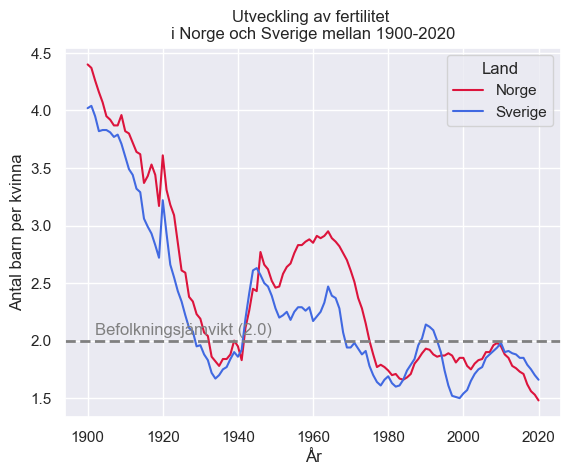

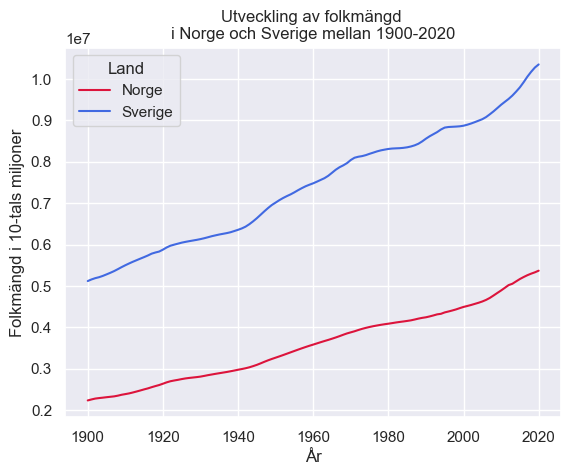

In [32]:
# VISUALISERING AV FERTILITET
sns.lineplot(data=final_no_se, x="År", y="Total fertilitet", hue="Land", palette=['crimson','royalblue'])
plt.ylabel("Antal barn per kvinna")
plt.title("Utveckling av fertilitet \ni Norge och Sverige mellan 1900-2020")
plt.axhline(2, color='gray', linestyle='--', linewidth=2)
plt.text(1902, 2.05, "Befolkningsjämvikt (2.0)", color='gray')
plt.show()

# VISUALISERING AV FOLKMÄNGD
sns.lineplot(data=final_no_se, x="År", y="Folkmängd", hue="Land", palette=['crimson','royalblue'])
plt.ylabel("Folkmängd i 10-tals miljoner")
plt.title("Utveckling av folkmängd \ni Norge och Sverige mellan 1900-2020")
plt.show()

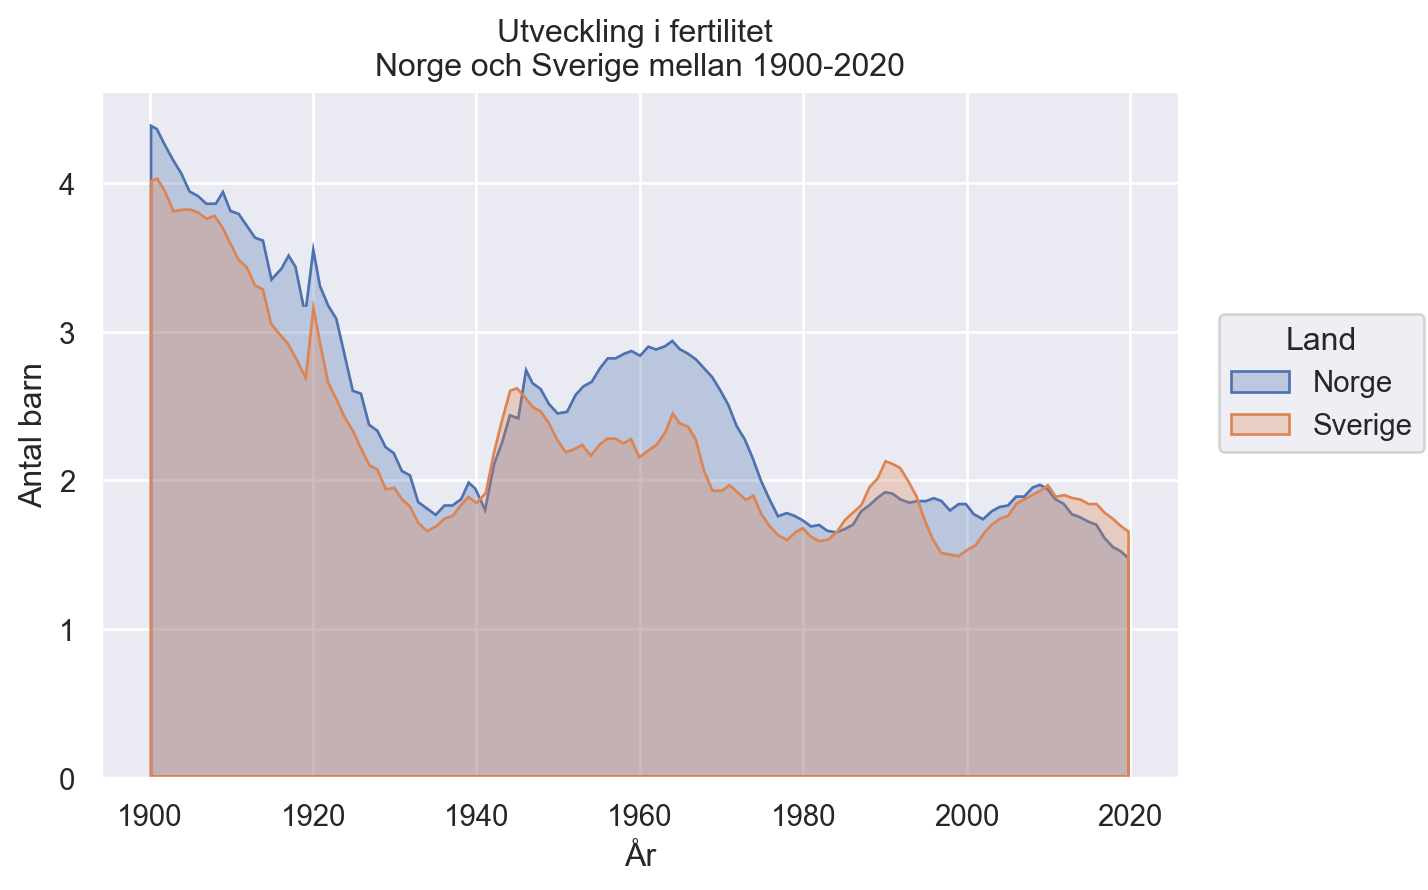

In [33]:
# ELLER ANVÄNDA SEABORN OBJECTS FÖR SNYGG AREA PLOT
import seaborn.objects as so

so.Plot(final_no_se, x='År', y='Total fertilitet', color='Land').add(
    so.Area(alpha=0.3)).label(y="Antal barn",title='Utveckling i fertilitet \nNorge och Sverige mellan 1900-2020')


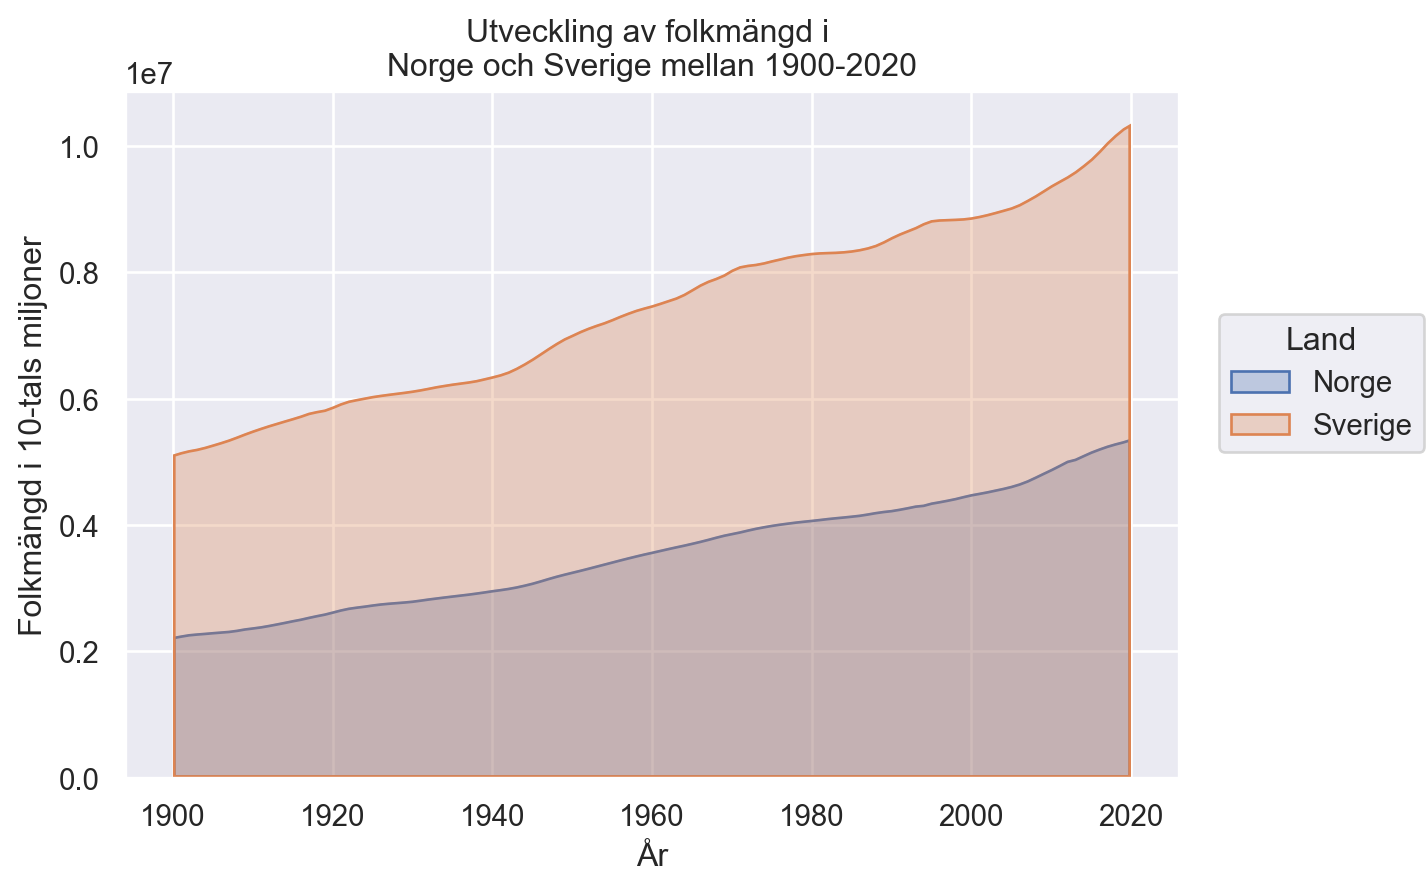

In [34]:


so.Plot(final_no_se, x="År", y='Folkmängd', color="Land").add(
    so.Area(alpha=0.3)).label(y="Folkmängd i 10-tals miljoner",title='Utveckling av folkmängd i \nNorge och Sverige mellan 1900-2020')

